# cdasws Example IDL Jupyter Notebook
This [Jupyter notebook](https://jupyter.org/) demonstates using the [cdasws](../CdasIdlLibrary.html) IDL library to access data from [cdaweb](https://cdaweb.gsfc.nasa.gov/) in the [IDL](https://www.nv5geospatialsoftware.com/docs/IDL_Kernel.html) programming language.

**Note:** This notebook is for the IDL version of cdasws.  Jupyter notebooks for the Python version of cdasws is available at [python cdasws notebooks](../#Jupyter_Notebook_Examples).  This notebook contains the following sections:

1. [Installation](#Installation)
2. [Setup](#Setup)
3. [Get Observatory Groups](#Get-Observatory-Groups)
4. [Get Instrument Types](#Get-Instrument-Types)
5. [Get Datasets](#Get-Datasets)
6. [Get Inventory](#Get-Inventory)
7. [Get Variable Names](#Get-Variable-Names)
8. [Get Data](#Get-Data)
9. [Binning Example](#Binning-Example)
10. [DOI Example](#DOI-Example)
11. [Additional Documentation](#Additional-Documentation)

## Installation
The following contains the procedure to install the [cdasws](https://cdaweb.gsfc.nasa.gov/WebServices/REST/CdasIdlLibrary.html) IDL library into your IDL environment.  There are different procedures for different versions of IDL.

### IDL 8.7.1 and higher
If you have an old version of the SPDF_CDAS package already installed, remove the old version.

In [ ]:
ipm, /remove, 'SPDF_CDAS'

Package "SPDF_CDAS" was removed

If the lastest version of the SPDF_CDAS package is not already installed, install it as shown below.

In [1]:
ipm, /install, 'https://cdaweb.gsfc.nasa.gov/WebServices/REST/SPDF_CDAS.zip'

Package: SPDF_CDAS, Version: 1.8.17 installed

You only need to install a particular version of the package once. You will need to restore the package everytime you restart your IDL session. Restore the package as shown below.

In [2]:
restore, !package_path + '/SPDF_CDAS/spdfcdas.sav'

### IDL 8.4.0 and newer
Download [spdfcdas.sav](https://cdaweb.gsfc.nasa.gov/WebServices/REST/spdfcdas.sav).  You will need to restore the package everytime you restart your IDL session. Restore the package as shown below.

In [3]:
;restore, getenv('HOME') + '/Downloads' + '/spdfcdas.sav'

## Setup
Create an SpdfCdas object that will be used in the code that follows.

In [4]:
cdas = obj_new('SpdfCdas')

## Get Observatory Groups
The following code demonstrates how to get the mission/observatory groups supported by cdaweb.

In [5]:
groups = cdas.getObservatoryGroups()
foreach group, groups[0:3] do print, group.getName()
print, '...'

ACE
AIM
AMPTE
ARTEMIS

...

## Get Intrument Types
The following code demonstrates how to get the intrument types supported by cdaweb.

In [6]:
instrTypes = cdas.getInstrumentTypes()
foreach instrType, instrTypes do print, instrType.getName()

Activity Indices
Electric Fields (space)
Electron Precipitation Bremsstrahlung
Energetic Particle Detector
Engineering
Ephemeris/Attitude/Ancillary
Gamma and X-Rays
Ground-Based HF-Radars
Ground-Based Imagers
Ground-Based Magnetometers, Riometers, Sounders
Ground-Based VLF/ELF/ULF, Photometers
Housekeeping
Imaging and Remote Sensing (ITM/Earth)
Imaging and Remote Sensing (Magnetosphere/Earth)
Imaging and Remote Sensing (Sun)
Linear Energy Transfer Spectrometer
Magnetic Fields (Balloon)
Magnetic Fields (space)
Mesospheric Gravity Waves (space)
Particles (space)
Plasma and Solar Wind
Pressure gauge (space)
Radio and Plasma Waves (space)
Spacecraft Potential Control
UV Imaging Spectrograph (Space)

## Get Datasets
The following code demonstrates how to find the datasets for a specific observatory group and instrument type.

In [7]:
datasets = cdas.getDatasets(observatoryGroups=['ACE'], instrumentTypes=['Magnetic Fields (space)'])
datasets[-1].print

AC_H0_MFI: H0 - ACE Magnetic Field 16-Second Level 2 Data - N. Ness (Bartol Research Institute)
TimeInterval: 1997-09-02T00:00:12.000Z to 2025-02-10T23:59:46.000Z

## Get Inventory
The following code demonstrates getting the available data inventory.

In [8]:
inventory = cdas.getInventory(datasets[-1].getId())
foreach interval, inventory.getTimeIntervals() do interval.print

TimeInterval: 1997-09-02T00:00:12.000Z to 2024-10-01T23:59:54.000Z
TimeInterval: 2024-10-02T23:59:59.000Z to 2025-02-10T23:59:46.000Z

## Get Variable Names
The following code demonstrates how to a dataset's variable names.

In [9]:
names = cdas.getVariableNames(datasets[-1].getId())
print, names

Magnitude BGSEc BGSM dBrms SC_pos_GSE SC_pos_GSM

## Get Data
The following code demonstrates how to access magnetic field measurements from the [ACE mission dataset](https://cdaweb.gsfc.nasa.gov/misc/NotesA.html#AC_H1_MFI).

In [10]:
d = spdfgetdata('AC_H2_MFI', ['Magnitude' , 'BGSEc'], ['2009-06-01T00:00:00.000Z', '2009-06-03T00:00:00.000Z'])

Use the standard IDL PLOT procedure to display the data.

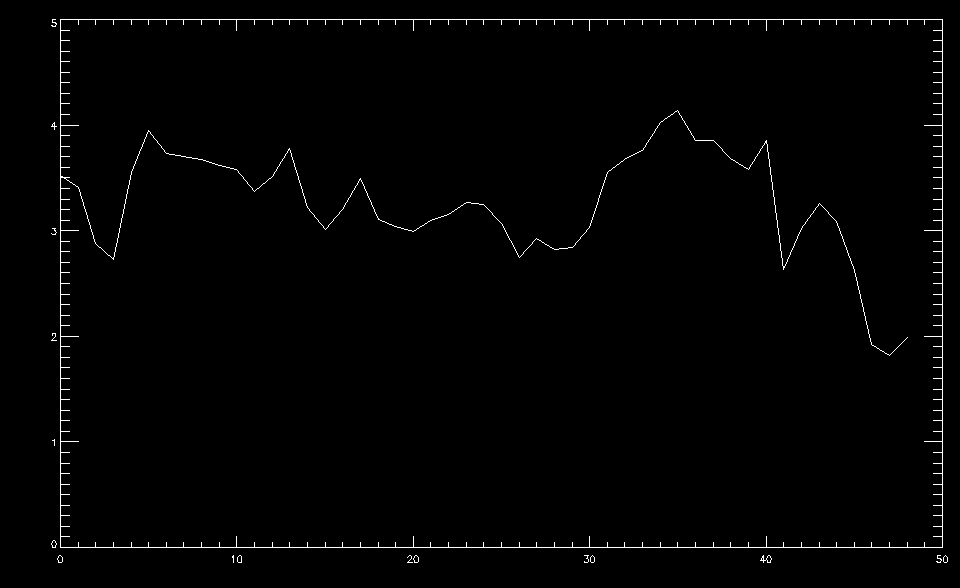

In [11]:
plot, d.magnitude.dat

Print the values.

In [12]:
print, d.magnitude.dat

3.52700 3.40500 2.88200 2.73000 3.54800 3.94800 3.73000 3.70300 3.67200 3.61600
 3.58300 3.37000 3.51300 3.77700 3.21800 3.01400 3.19700 3.49900 3.10900 3.03900
 2.99700 3.09500 3.15200 3.26500 3.25000 3.07000 2.75000 2.92400 2.82200 2.83700
 3.02900 3.54900 3.67500 3.76300 4.02500 4.13600 3.85400 3.85700 3.68800 3.58300
 3.85200 2.63600 3.01900 3.25700 3.09100 2.61900 1.92300 1.81800 1.99100

Use the [cdawlib plotmaster function](https://spdf.gsfc.nasa.gov/CDAWlib.html#plotmaster) to plot the data.

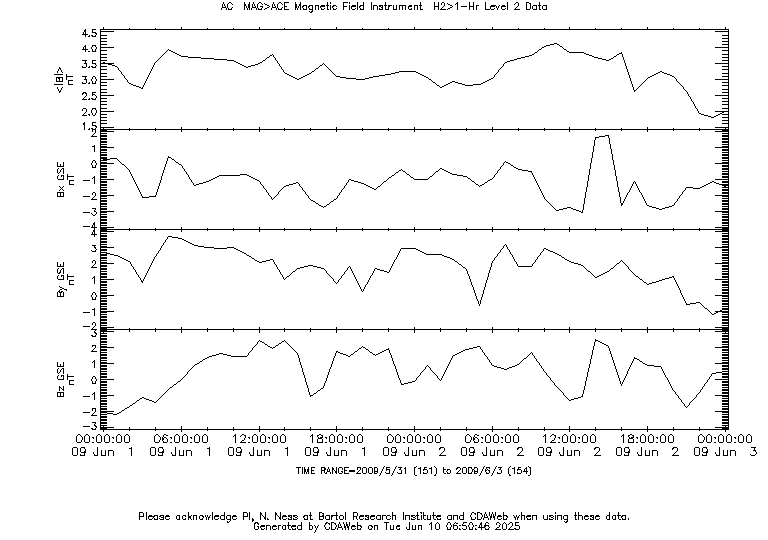

Setting font scaling to: 1.40000
DEBUG evaluate_varstruct: varname = Epoch
DEBUG evaluate_varstruct: varname = Magnitude
DEBUG evaluate_varstruct: varname = BGSEc

In [13]:
status=plotmaster(d,/auto, xsize=768)

## Binning Example
For analysis, it is often useful to place two datasets that have different timestamps on the same time grid (with optional spike removal).  The following demonstrates doing this with cdasws and the datasets [AC_H0_SWE](/misc/NotesA.html#AC_H0_SWE) and [AC_H2_SWE](/misc/NotesA.html#AC_H2_SWE).  For more information on binning, see [binning in cdaweb](/CDAWeb_Binning_readme.html).

### Display Original Data
Get and gets and displays the original, unbinned data.

In [14]:
dataset0 = 'AC_H0_SWE'
variables = ['Np']
time = ['1998-02-04T00:00:00Z', '1998-02-06T00:00:00Z']
data0 = spdfgetdata(dataset0, variables, time)
print, data0.epoch.dat[0:10]
print, data0.np.dat[0:10]
dataset1 = 'AC_H2_SWE'
data1 = spdfgetdata(dataset1, variables, time)
print, data1.epoch.dat[0:10]
print, data1.np.dat[0:10]

6.3053770e+13 6.3053770e+13 6.3053770e+13 6.3053770e+13 6.3053770e+13 6.3053770e+13 6.3053770e+13 6.3053770e+13
 6.3053770e+13 6.3053770e+13 6.3053770e+13

-1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31
 -1.00000e+31

6.3053770e+13 6.3053773e+13 6.3053777e+13 6.3053780e+13 6.3053784e+13 6.3053788e+13 6.3053791e+13 6.3053795e+13
 6.3053798e+13 6.3053802e+13 6.3053806e+13

-1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31 -1.00000e+31
 -1.00000e+31

### Bin Data
The following code gets data after it has been binned with 60 second time intervals and any missing values created by interpolation.

In [15]:
data0 = spdfgetdata(dataset0, variables, time, $
                binInterval=60.0D, binInterpolateMissingValues=1, $
                binSigmaMultiplier=4)
print, data0.epoch.dat[0:10]
print, data0.np.dat[0:10]
data1 = spdfgetdata(dataset1, variables, time, $
                binInterval=60.0D, binInterpolateMissingValues=1, $
                binSigmaMultiplier=4)
print, data1.epoch.dat[0:10]
print, data1.np.dat[0:10]

6.3053770e+13 6.3053770e+13 6.3053770e+13 6.3053770e+13 6.3053770e+13 6.3053770e+13 6.3053770e+13 6.3053770e+13
 6.3053770e+13 6.3053770e+13 6.3053770e+13

16.3343 16.3343 16.3343 16.3343 16.3343 16.3343 16.3343 16.3343 16.3343 16.3343
 16.3343

6.3053770e+13 6.3053773e+13 6.3053777e+13 6.3053780e+13 6.3053784e+13 6.3053788e+13 6.3053791e+13 6.3053795e+13
 6.3053798e+13 6.3053802e+13 6.3053806e+13

16.6551 16.6551 16.6551 16.6551 16.6551 16.6551 16.6551 16.6551 16.6551 16.6551
 16.6551

### Compare Data
The following code compares the binned data from the two datasets by plotting the values.

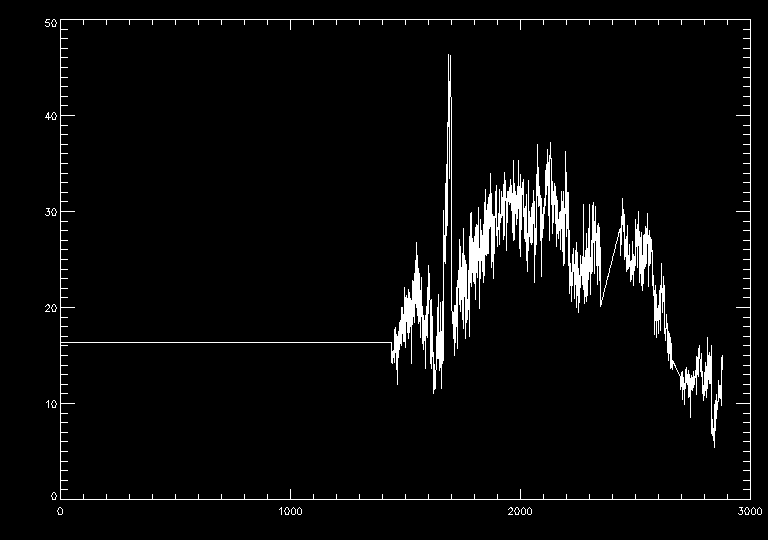

In [16]:
plot, data0.np.dat

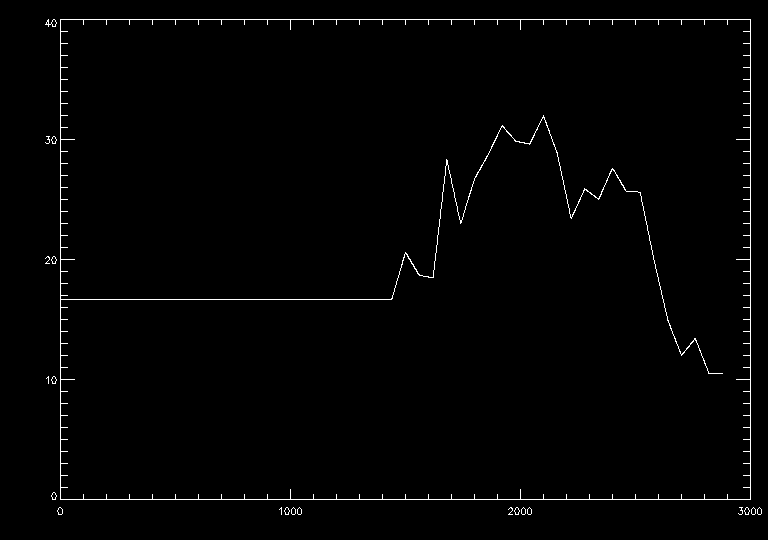

In [17]:
plot, data1.np.dat

## DOI Example
The following code gets data from a dataset using the  dataset's [Digital Object Identifier](https://www.doi.org/) and displays the dataset's values.

ISEE2_60SEC_MFI, DOI: 10.21978/p8t923, spase://NASA/NumericalData/ISEE2/MAG/PT1M

BX BY BZ BTOT

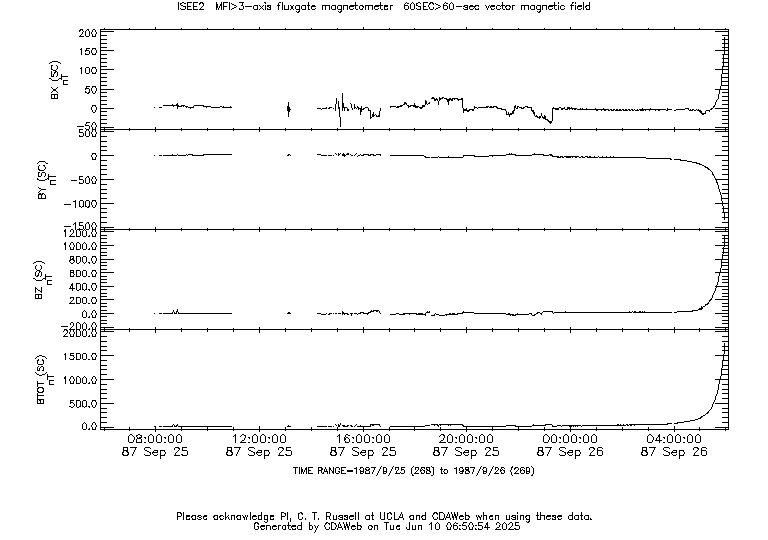

Setting font scaling to: 1.40000
DEBUG evaluate_varstruct: varname = Epoch
DEBUG evaluate_varstruct: varname = BX
DEBUG evaluate_varstruct: varname = BY
DEBUG evaluate_varstruct: varname = BZ
DEBUG evaluate_varstruct: varname = BTOT

In [18]:
ds = cdas.getDatasets(idPattern='ISEE2_60SEC_MFI')
print, ds[0].getId(), ', DOI: ', ds[0].getDoi(), ', ', ds[0].getResourceId()
iseeVars = cdas.getVariableNames(ds[0].getId())
print, iseeVars[0:3]
iseeInventory = cdas.getInventory(ds[0].getId())
iseeIntervals = iseeInventory.getTimeIntervals()
iseeStop = iseeIntervals[-1].getStop()
iseeStart = iseeStop - 1.0
iseeData = spdfgetdata(ds[0].getDoi(), iseeVars[0:3], [iseeStart, iseeStop])
status = plotmaster(iseeData, /auto, xsize=768)

## Additional Documentation
View the [cdasws API](../idl/api/) for additional functions.